# **Lesson 3 - Quantum Computers as Simulators** 

### 1. The Ising Model

A potential application of quantum computers is that of simulators for physical phenomena. Since, according to quantum mechanics, nature is not classical at its most fundamental levels, quantum computers provide a cleaner and more controllable stand-in to simulate processes in the natural word [TO BE REVIEWED]. In this notebook, we will work with the a toy example involving the **Ising model**. The Ising model is simple theoretical description of ferromagnetism created by Wilhelm Lenz in 1920 and detailed by Ernst Ising later in 1925. It successful predicts the phase transition of a ferromagnetic material to that of a paramagnetic one once a certain temperature threshold is passed. The setup begins with $N$ number of atoms arranged in a lattice,

[DIAGRAM]

Each atom possesses a magnetic dipole moment $\mu_i$ and a spin described by the discrete variable $\sigma$. When the atom is in the spin-up state $\sigma = +1$ while $\sigma = -1$ for spin-down. The total energy of this system is described the following Hamiltonian classical $H$,

$$
H = -\underbrace{\sum_{<ij>} J_{ij} \sigma_i \sigma_j}_{\text{interaction}} - \underbrace{\sum_{i=1}^N \mu_i h_i \sigma_i}_{\text{magnetic field}}
$$

where $h_i$ is the magnetic field strength at the $i$-th site and $<ij>$ denotes all neighbour pairs. For example, when we have two atoms $N=2$, the interaction term is $-J_{12} \sigma_1 \sigma_2$ and when $N=3$ we have $-(J_{12} \sigma_1 \sigma_2 + J_{23} \sigma_2 \sigma_3)$. The interaction term is constructed in such a way that alignments in spin between neighbouring atoms contribute to lower energies. This is evident from $\sigma_i \sigma_j = (\pm 1)(\pm 1) = +1$ being the contribution when spins align. Note that all contributions are weighted by the strength of the pair-wise interaction $J_{ij}$. Let us assume that we have two atoms $N = 2$, the magnetic field is uniform such that $h_i = h$ for all $i$ and that all atoms have the same dipole strength $\mu$. In this case, the Hamiltonian is, 

$$
H = - J \sigma_1 \sigma_2 - \mu h (\sigma_1 + \sigma_2)
$$

This Hamiltonian is purely classical, but we can write in using quantum formalism. We map each atom to a qubit that can either be in the state $\ket
{0}$ (spin-up) or $\ket{1}$ (spin-down) such that our computational basis is $\{\ket(0), \ket(1)\}$. Our discrete variables $\sigma_i$ are promoted to Pauli $Z$ gates,

$$
\hat{H} = - J \hat{Z_1} \hat{Z_2} - \mu h (\hat{Z_1} + \hat{Z_2})
$$

Our Hamiltonian $\hat{H}$ is the quantum encoding (using qubits) of the classical Ising model for two atoms. Solving for the energy eigenvalues is trivial because we only have four possible qubit configurations that have the energies $E_1$, $E_2$, $E_3$ and $E_4$,

$$
\hat{H} = \begin{pmatrix} \bra{00}H\ket{00}&1&4&4 \\ 0&\bra{01}H\ket{01}&4&4 \\ 0&1&\bra{01}H\ket{01}&4 \\ 0&1&4&\bra{11}H\ket{11} \end{pmatrix}

= \begin{pmatrix} E_1&0&0&0 \\ 0&E_2&0&0 \\ 0&0&E_3&0 \\ 0&0&0&E_4 \end{pmatrix}

= \begin{pmatrix} -J - 2\mu h &0&0&0 \\ 0&J&0&0 \\ 0&0&J&0 \\ 0&0&0&  -J + 2\mu h \end{pmatrix}
$$

### 2. Qiskit

Now that we have established all the underlying theory, we want to use Qiskit to run the equivalent qubit system. We start by importing all required modules,

In [20]:
# Importing Qiskit libraries,
import qiskit
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Importing other libraries,
import matplotlib.pyplot as plt

We know from our calculations that the energy of our system is minimised when both qubits are in the $\ket{0}$ states (corresponding to both atoms in the spin-up state). Therefore, as a sanity check,
we want to check if it has an energy $-J$. Firstly, we construct a quantum circuit to create the state $\ket{00}$,

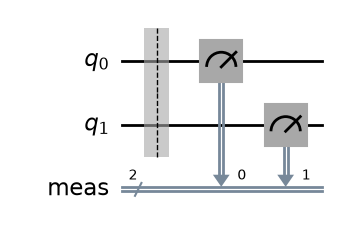

In [16]:
qc = QuantumCircuit(2)
qc.measure_all()
qc.draw(output="mpl")

Writing the function responsible for running the circuit on IBM hardware,

In [17]:
def run_ibm(circuit, backend, shots):
    """
    Runs a quantum circuit on a specified backend and returns the measurement counts.

    Args:
        circuit (QuantumCircuit): The quantum circuit to run.
        backend: The Qiskit backend (real device or simulator).
        shots (int): The number of shots to run the circuit.

    Returns:
        dict: A dictionary of measurement counts.
    """

    # Transpiling the circuit,
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(circuit)
    sampler = Sampler(mode=backend)

    # Running the cicuit,
    job = sampler.run([isa_circuit], shots=shots)

    # Extracting the result,
    result = job.result()

    return result

Running the circuit on IBM quantum computers,

In [18]:
# Finding token,
token = open("api_token.txt", "r").read()

# Runnning the service,
service = QiskitRuntimeService()
backend = service.least_busy(operational=True,
                             simulator=False)
print(f"Running on {backend}")
result = run_ibm(circuit=qc, backend=backend, shots=100)


qiskit_runtime_service.__init__:WARNING:2026-09-03 21:02:48,102: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: From Zero to Quantum. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-09-03 21:02:48,477: Loading instance: From Zero to Quantum, plan: open
qiskit_runtime_service.backends:WARNING:2026-09-03 21:02:50,777: Using instance: From Zero to Quantum, plan: open


Running on <IBMBackend('ibm_fez')>


We see that only the state $\ket{00}$ was produced,

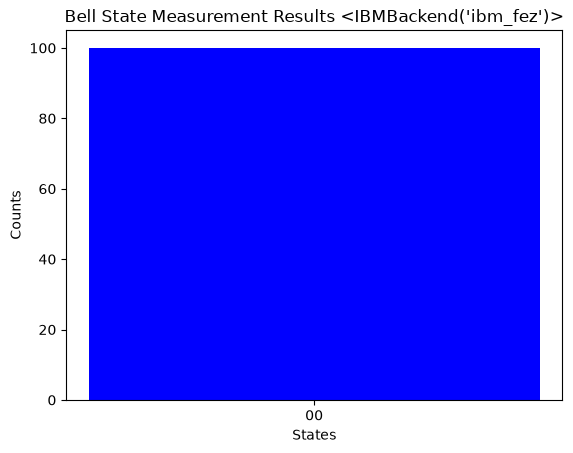

In [19]:
# Extracting counts,
counts = result[0].data.meas.get_counts()

# Plotting,
plt.bar(counts.keys(), counts.values(), color=["blue", "lightblue"])
plt.xlabel("States")
plt.ylabel("Counts")
plt.title(f"Bell State Measurement Results {backend}")
plt.show()

A `SparsePauliOp` in Qiskit is a way to store a list of these Pauli operators along with their numerical coefficients. These Pauli operators are the observables that we want the quantum computer to measure — the quantities that tell us about the system. Using `Estimator`, we can compute the average value of each observable on our state and combine them according to the coefficients in the Hamiltonian to get the total energy.

In [ ]:
# Hamiltonian parameters,
J = 1.0
h = 1.0
mu = 1

# Constructing the Hamiltonian,
hamiltonian = SparsePauliOp.from_list(
    [("ZZ", -J),
     ("ZI", -mu*h),
     ("IZ", -mu*h)])

### References

Computational Physics - The Ising model (2006). Richard Fitzpatrick. URL: https://farside.ph.utexas.edu/teaching/329/lectures/node110.html


Quantum Machine Learning - 09 - Classical Ising Model (2019). Peter Wittek. URL: https://www.youtube.com/watch?v=Wy9YoEYv-fA